In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
from sklearn.neighbors import KernelDensity 
from sklearn.model_selection import GridSearchCV, LeaveOneOut
from sklearn.mixture import GaussianMixture
from scipy.spatial.distance import jensenshannon
import scipy.stats as st

In [3]:
#upload CSV of SDSS
ra, dec, z, phot_u, phot_g, phot_r, phot_i, phot_z  = np.loadtxt('sdss_cutout.csv', unpack=True,skiprows=1, delimiter=',')
print (z)

[0.09762917 0.06773683 0.06335044 ... 0.10209855 0.06914159 0.07091606]


Task 1 

In [14]:
#cut = (d["z"] > 0.08) & (d["z"]< 0.12)

In [4]:
cut_2 = (z > 0.09) & (z < 0.1)
ra, dec, z, phot_u, phot_r = ra[cut_2], dec[cut_2], z[cut_2], phot_u[cut_2], phot_r[cut_2]

Text(0.5, 1.0, 'RA vs. DEC')

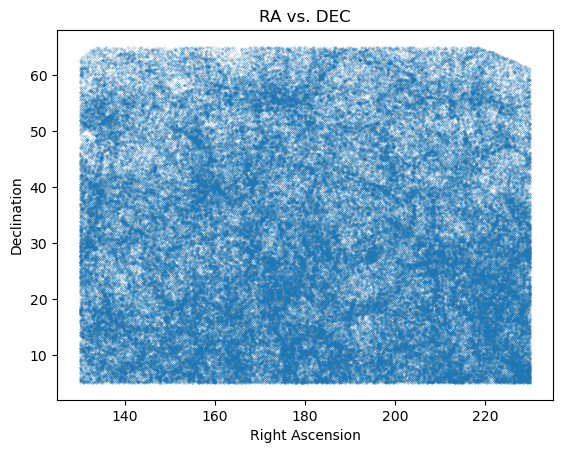

In [3]:
plt.scatter(ra, dec, s=0.01)
plt.xlabel ('Right Ascension')
plt.ylabel ('Declination')
plt.title ('RA vs. DEC')

In [7]:
phot_color = phot_u - phot_r
red = phot_color>2.3
blue = phot_color<=2.3
r_red  = phot_r[red]
r_blue = phot_r[blue]

n_red, n_blue = len(r_red), len(r_blue)
print(ra,dec)

[130.08995054 130.66302697 130.26130435 ... 147.17785501 147.10407565
 146.4994137 ] [52.17809664 50.0718964  51.80004422 ... 45.63545059 45.72888659
 46.31268362]


Text(0.5, 1.0, 'RA vs. DEC')

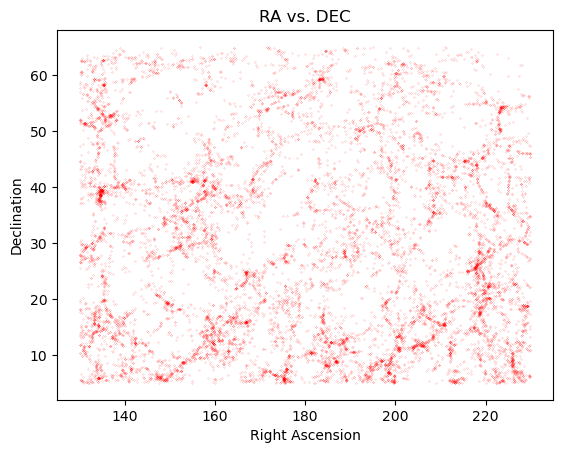

In [18]:
plt.scatter(ra[red], dec[red], s=0.01, color = 'r')
plt.xlabel ('Right Ascension')
plt.ylabel ('Declination')
plt.title ('RA vs. DEC')

Text(0.5, 1.0, 'RA vs. DEC')

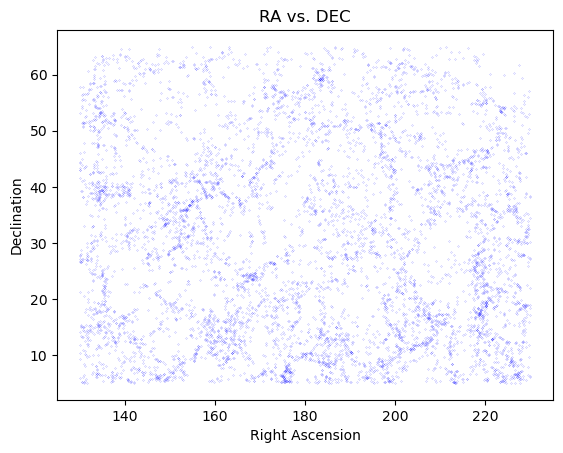

In [19]:
plt.scatter(ra[blue], dec[blue], s=0.01, color = 'b')
plt.xlabel ('Right Ascension')
plt.ylabel ('Declination')
plt.title ('RA vs. DEC')

Task 2

In [5]:
data=np.column_stack((ra, dec))
data_sub = data[np.random.choice(len(ra), size=2000, replace=False)]

In [6]:
data_sub

array([[157.10837643,  43.04885381],
       [183.86060782,  43.03599453],
       [182.82127157,  54.86108977],
       ...,
       [173.52169768,   7.56188124],
       [228.03913752,   5.50349811],
       [177.00224126,  54.80679685]], shape=(2000, 2))

In [ ]:
bandwidths=np.geomspace(0.05,3.0,30) 
grid=GridSearchCV(KernelDensity(kernel='gaussian'), 
                  {'bandwidth': bandwidths},cv=LeaveOneOut()) 
grid.fit(data_sub) #data has shape (N,2) for2D 
h_opt=grid.best_params_['bandwidth']
cv_score = grid.cv_results_['mean_test_score']

print(cv_score)

In [218]:
print(h_opt)

1.761110261860995


In [242]:
bandwidths=np.geomspace(1,10,30) 
grid=GridSearchCV(KernelDensity(kernel='gaussian'), 
                  {'bandwidth': bandwidths},cv=5) 
grid.fit(data_sub) #data has shape (N,2) for2D 
h_opt2=grid.best_params_['bandwidth']
cv_score = grid.cv_results_['mean_test_score']

print(cv_score)

[-3525.02155224 -3513.11168069 -3503.98761818 -3497.05578852
 -3491.84442972 -3487.98630187 -3485.20467846 -3483.2992575
 -3482.13013532 -3481.60049973 -3481.6405856  -3482.19555369
 -3483.21847926 -3484.66780177 -3486.50753202 -3488.7084892
 -3491.2493651  -3494.11697287 -3497.30552002 -3500.81522218
 -3504.65090675 -3508.82119408 -3513.33844728 -3518.21929793
 -3523.48543106 -3529.16440382 -3535.29039175 -3541.90480142
 -3549.05670543 -3556.80312219]


In [243]:
print(h_opt2)

2.043359717856942


In [239]:
data = np.column_stack((ra, dec))
std_ra = np.std(data_sub[:,0])
std_dec = np.std(data_sub[:,1])
std_hat =  (std_ra**2 + std_dec**2)**(1/2)

h_sil = 1.06 * std_hat * len(data_sub)**(-1/5)

print(h_sil)

7.583798119375348


In [8]:
colors = phot_color[:,np.newaxis]

In [182]:

bic_scores=[]
models = dict()
for k in range(1,7): 
    gm=GaussianMixture(n_components=k, n_init=10).fit(colors)
    bic_scores.append(gm.bic(colors)) 
    models[k] = gm 
    print(bic_scores)
  


[577064.1629687388]
[577064.1629687388, 561820.4582779177]
[577064.1629687388, 561820.4582779177, 545897.633469921]
[577064.1629687388, 561820.4582779177, 545897.633469921, 545410.02579008]
[577064.1629687388, 561820.4582779177, 545897.633469921, 545410.02579008, 544837.5770633288]
[577064.1629687388, 561820.4582779177, 545897.633469921, 545410.02579008, 544837.5770633288, 543495.2266899309]


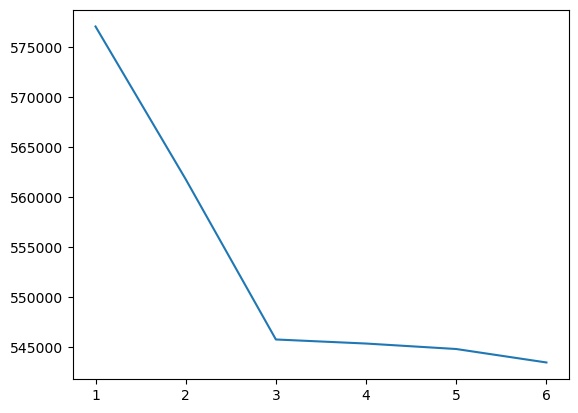

In [45]:
plt.plot(range(1,7), bic_scores)

(array([3.0000e+00, 1.0000e+00, 5.0000e+00, 2.0000e+00, 2.0000e+00,
        8.0000e+00, 5.0000e+00, 1.4000e+01, 1.8000e+01, 1.0000e+01,
        1.2000e+01, 1.7000e+01, 1.9000e+01, 3.0000e+01, 3.2000e+01,
        5.6000e+01, 1.0700e+02, 2.0500e+02, 3.6900e+02, 7.3800e+02,
        1.2610e+03, 1.8950e+03, 2.8140e+03, 3.6400e+03, 4.5410e+03,
        5.3980e+03, 6.1130e+03, 6.8090e+03, 7.2820e+03, 7.5970e+03,
        7.6920e+03, 8.0630e+03, 7.9620e+03, 8.0980e+03, 7.9650e+03,
        7.6410e+03, 7.6940e+03, 7.5010e+03, 7.7900e+03, 8.0870e+03,
        8.5600e+03, 9.2330e+03, 1.0293e+04, 1.1762e+04, 1.3422e+04,
        1.4874e+04, 1.5919e+04, 1.5809e+04, 1.5230e+04, 1.3620e+04,
        1.2018e+04, 9.9970e+03, 8.2310e+03, 6.6470e+03, 5.4980e+03,
        4.2700e+03, 3.5180e+03, 2.7150e+03, 2.2220e+03, 1.6520e+03,
        1.3480e+03, 1.0330e+03, 7.6400e+02, 6.0600e+02, 4.9100e+02,
        3.7400e+02, 3.7100e+02, 2.6800e+02, 2.3000e+02, 2.0500e+02,
        1.6900e+02, 1.4300e+02, 1.0500e+02, 9.10

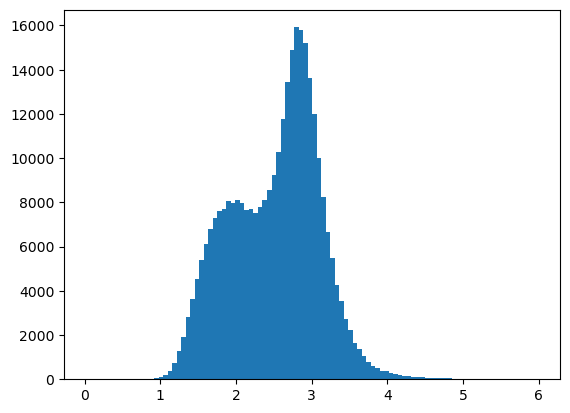

In [56]:
plt.hist(colors, bins=100)

In [61]:
delta_bic = []
for k in range(1,6):
    delta_bic.append(bic_scores[k-1]-bic_scores[k])
    print (delta_bic)


[15261.96769925952]
[15261.96769925952, 16009.904345260235]
[15261.96769925952, 16009.904345260235, 405.91206115169916]
[15261.96769925952, 16009.904345260235, 405.91206115169916, 547.0126129541313]
[15261.96769925952, 16009.904345260235, 405.91206115169916, 547.0126129541313, 1345.1436688208487]


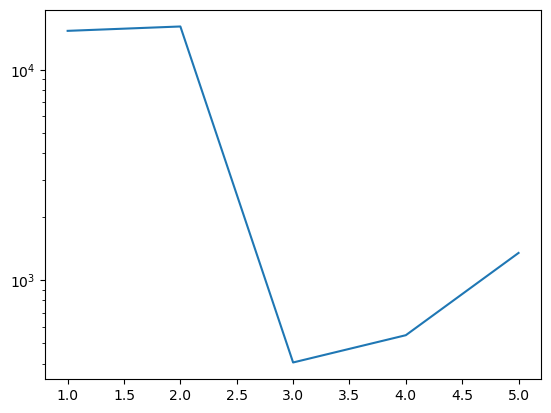

In [62]:
plt.plot(range(1,6), delta_bic)
plt.yscale('log')

In [194]:
tau = models[2].predict_proba(colors)
print (tau)

[[0.87476488 0.12523512]
 [0.97619523 0.02380477]
 [0.15453081 0.84546919]
 ...
 [0.99094803 0.00905197]
 [0.01797453 0.98202547]
 [0.04036628 0.95963372]]


In [102]:
print(gm_arr[2].converged_)

True


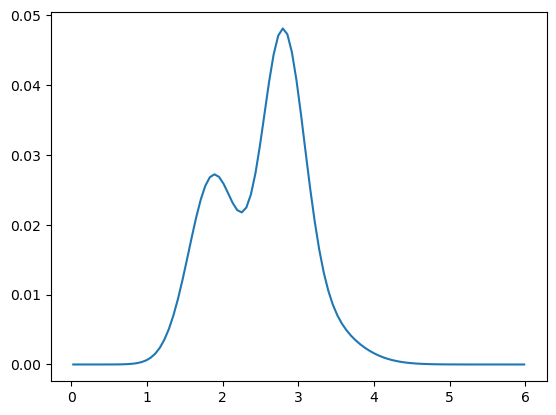

In [193]:
x= np.linspace(colors.min(), colors.max(), 100).reshape(-1, 1)
log_probs = models[3].score_samples(x)
sum_of_scores = (np.exp(log_probs)).sum()
probs = np.exp(log_probs) / sum_of_scores
plt.plot(x, probs)

(array([1.57427247e-04, 5.24757489e-05, 2.62378744e-04, 1.04951498e-04,
        1.04951498e-04, 4.19805991e-04, 2.62378744e-04, 7.34660484e-04,
        9.44563479e-04, 5.24757489e-04, 6.29708986e-04, 8.92087730e-04,
        9.97039228e-04, 1.57427247e-03, 1.67922396e-03, 2.93864194e-03,
        5.61490513e-03, 1.07575285e-02, 1.93635513e-02, 3.87271027e-02,
        6.61719193e-02, 9.94415441e-02, 1.47666757e-01, 1.91011726e-01,
        2.38292376e-01, 2.83264092e-01, 3.20784253e-01, 3.57307374e-01,
        3.82128403e-01, 3.98658264e-01, 4.03643460e-01, 4.23111963e-01,
        4.17811912e-01, 4.24948614e-01, 4.17969340e-01, 4.00967197e-01,
        4.03748412e-01, 3.93620592e-01, 4.08786084e-01, 4.24371381e-01,
        4.49192410e-01, 4.84508589e-01, 5.40132883e-01, 6.17219758e-01,
        7.04329501e-01, 7.80524288e-01, 8.35361446e-01, 8.29589114e-01,
        7.99205655e-01, 7.14719699e-01, 6.30653550e-01, 5.24600061e-01,
        4.31927889e-01, 3.48806303e-01, 2.88511667e-01, 2.240714

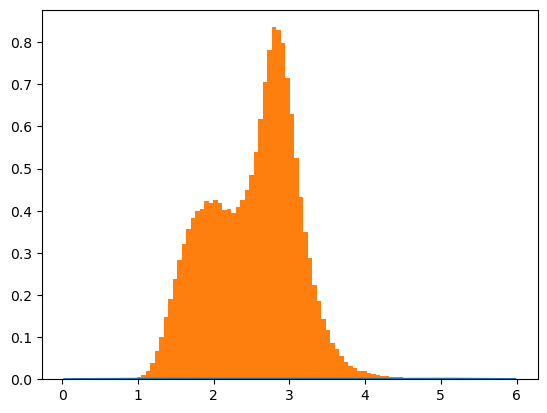

In [92]:
x= np.linspace(colors.min(), colors.max(), 1000).reshape(-1, 1)
log_probs = models[2].score_samples(x)
sum_of_scores = (np.exp(log_probs)).sum()
probs = np.exp(log_probs) / sum_of_scores

plt.plot(x, probs)
plt.hist(colors, density=True, bins=100)

In [195]:
means = models[2].means_.ravel()
red = np.argmax(means)
blue = np.argmin(means)
tau_red = tau[:, red]
tau_blue = tau[:, blue]
#tau_something = tau[:,2]
print(means)
print(red)
print(blue)

[2.84106674 1.87420631]
0
1


In [192]:
print(tau)
print(tau_red)
print(tau_blue)
print(tau_something)

[[2.11169094e-01 1.00466929e-01 6.88363977e-01]
 [1.89212296e-01 1.29682626e-02 7.97819441e-01]
 [7.23140635e-02 9.09823365e-01 1.78625717e-02]
 ...
 [2.00868076e-01 4.37399193e-03 7.94757932e-01]
 [2.16136928e-02 9.78277861e-01 1.08446613e-04]
 [3.07661978e-02 9.68392467e-01 8.41334892e-04]]
[0.21116909 0.1892123  0.07231406 ... 0.20086808 0.02161369 0.0307662 ]
[0.10046693 0.01296826 0.90982336 ... 0.00437399 0.97827786 0.96839247]
[6.88363977e-01 7.97819441e-01 1.78625717e-02 ... 7.94757932e-01
 1.08446613e-04 8.41334892e-04]


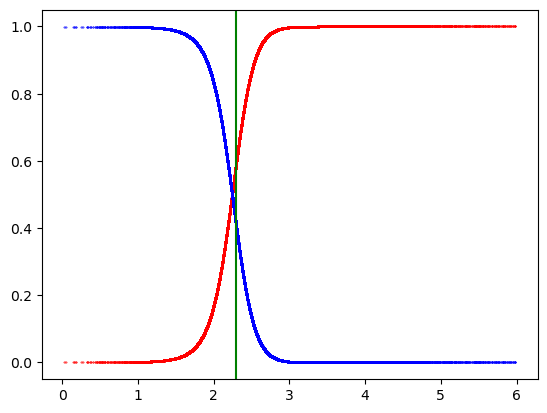

In [196]:
plt.scatter(colors, tau_red, s=0.1, color = 'r')
plt.scatter(colors, tau_blue, s=0.1, color='b')
#plt.scatter(colors, tau_something, s=0.1)
plt.axvline(2.3, color = 'g')

task 4

In [10]:
def h_sil (data):
    return 1.06 * np.std(data) * len(data)**(-1/5)

In [23]:
kde_opt = KernelDensity(kernel ='gaussian', bandwidth = 1).fit(data)
kde = np.exp(kde_opt.score_samples(data))

q25 = np.quantile(kde,0.25)
q75 = np.quantile(kde, 0.75)

high = kde >= q75
low =  kde <= q25

c_high = colors[high]
c_low = colors[low]

sil_low = h_sil(c_low)
sil_high = h_sil(c_high)

c_low,c_high

(array([[2.982954],
        [1.705348],
        [3.112545],
        ...,
        [3.015953],
        [2.394199],
        [1.950851]], shape=(5052, 1)),
 array([[2.436207],
        [2.040688],
        [3.066776],
        ...,
        [2.520376],
        [2.989011],
        [2.343404]], shape=(5052, 1)))

In [24]:


kde_low=KernelDensity(kernel='gaussian', bandwidth=sil_low).fit(c_low)
kde_high=KernelDensity(kernel='gaussian', bandwidth=sil_high).fit(c_high)


cgrid=np.linspace(colors.min(),colors.max(), 500)
p_low =np.exp(kde_low.score_samples(cgrid[:,np.newaxis])) 
p_high=np.exp(kde_high.score_samples(cgrid[:,np.newaxis])) 
dc= cgrid[1]-cgrid[0]
p_low /=p_low.sum()*dc; p_high /=p_high.sum()*dc 
D_JS = jensenshannon(p_low,p_high)**2 #returnssqrt(D_JS),sosquareit


In [25]:
D_JS

np.float64(0.016329672273315714)

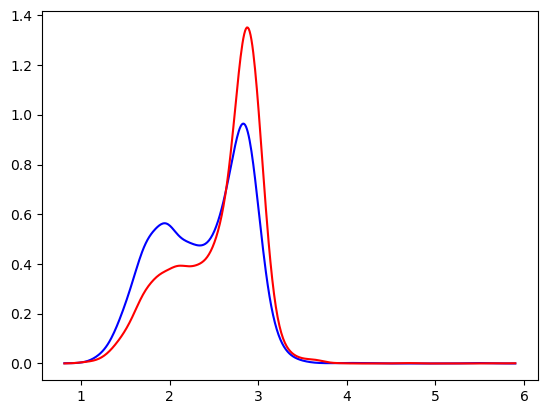

In [26]:
plt.figure()
plt.plot(cgrid, p_low, color = 'b')
plt.plot(cgrid, p_high, color = 'r')


task 5 